In [ ]:
DATA_ROOT = "/kaggle/input/datasets/matteofioretti/deepfake-processed/processed"
import os
print(os.path.exists(DATA_ROOT))
print(os.listdir(DATA_ROOT))

In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# ── Device ─────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Data root: {DATA_ROOT}")


In [ ]:
# transformations for train/val/test

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform  = transforms.Compose([transforms.RandomResizedCrop(224),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean, std)])

val_transform = transforms.Compose([transforms.Resize(256),
                                   transforms.CenterCrop(224),
                                   transforms.ToTensor(),
                                   transforms.Normalize(mean, std)])

test_transform = transforms.Compose([transforms.Resize(256),
                                   transforms.CenterCrop(224),
                                   transforms.ToTensor(),
                                   transforms.Normalize(mean, std)])

In [ ]:
# data paths
train_path = os.path.join(DATA_ROOT, "train")
val_path = os.path.join(DATA_ROOT, "val")
test_path = os.path.join(DATA_ROOT, "test")

# datasets creation
train_dataset = ImageFolder(train_path, transform=train_transform)
val_dataset = ImageFolder(val_path, transform=val_transform)
test_dataset = ImageFolder(test_path, transform=test_transform)

# dataloader creation (train is shuffled)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False)


In [ ]:
# Test to check everything works
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

In [ ]:
# checking size coherence
X, y = next(iter(train_dataloader))
X.shape, y.shape

In [ ]:
# Model definition
from torchvision.models import resnet50, ResNet50_Weights

"""
This downloads the ResNet-50 weights pretrained on ImageNet. T<
he weights are cached locally after the first download so you only download once.
"""
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

In [ ]:
"""
Replace fc of resnet50 of size (2048,1000) with a
fc of size (2048,2) since we are performing binary classification
"""
model.fc = nn.Linear(2048,2)
nn.init.xavier_uniform_(model.fc.weight)
model = model.to(device)

In [ ]:
# define optimizer
params_1x = [param for name, param in model.named_parameters()
                              if not name.startswith("fc")]
optimizer = torch.optim.Adam([{"params": params_1x, "lr": 1e-4 },
                             {"params": model.fc.parameters(), "lr": 1e-3 }])

In [ ]:
for split in ["train", "val", "test"]:
    for cls in ["real", "fake"]:
        path = os.path.join(DATA_ROOT, split, cls)
        count = len(os.listdir(path))
        print(f"{split}/{cls}: {count}")

There is a class imbalance in the dataset, roughly 3:1 fake:ratio, therefore I will use weighted loss


In [ ]:
num_real = 7999
num_fake = 22982
total_samples = num_real + num_fake

weight_real = total_samples / (2*num_real)
weight_fake = total_samples / (2*num_fake)

In [ ]:
weight = torch.tensor([weight_fake, weight_real]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weight,reduction="mean")

In [ ]:
num_epochs = 8
SMOKE_TEST = False       # set False for the real run
MAX_BATCHES = 5            # only used when SMOKE_TEST is True

min_val_loss = float("inf")

for i in range(num_epochs):
    model.train()
    train_loss = 0
    train_acc = 0
    for b, batch in enumerate(train_dataloader):
        if SMOKE_TEST and b >= MAX_BATCHES:
            break
        optimizer.zero_grad()
        X, y = batch
        X, y = X.to(device), y.to(device)
        y_hat = model(X)
        batch_loss = loss_fn(y_hat, y)
        preds = torch.max(y_hat, dim=1).indices
        batch_accuracy = torch.sum(y == preds) / y.shape[0]
        batch_loss.backward()
        optimizer.step()
        train_loss += batch_loss.item()
        train_acc += batch_accuracy.item()

    # number of batches we actually ran (so the average is correct)
    n_train = (b + 1)
    train_loss = train_loss / n_train
    train_acc = train_acc / n_train
    print(f"train_loss epoch_{i}: {train_loss}")
    print(f"train_accuracy epoch_{i}: {train_acc}")

    model.eval()
    val_loss = 0
    val_acc = 0
    for b, batch in enumerate(val_dataloader):
        if SMOKE_TEST and b >= MAX_BATCHES:
            break
        with torch.no_grad():
            X, y = batch
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            batch_loss = loss_fn(y_hat, y)
            preds = torch.max(y_hat, dim=1).indices
            batch_accuracy = torch.sum(y == preds) / y.shape[0]
            val_loss += batch_loss.item()
            val_acc += batch_accuracy.item()

    n_val = (b + 1)
    val_loss = val_loss / n_val
    val_acc = val_acc / n_val
    print(f"val_loss epoch_{i}: {val_loss}")
    print(f"val_accuracy epoch_{i}: {val_acc}")

    if val_loss < min_val_loss:
        min_val_loss = val_loss
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")

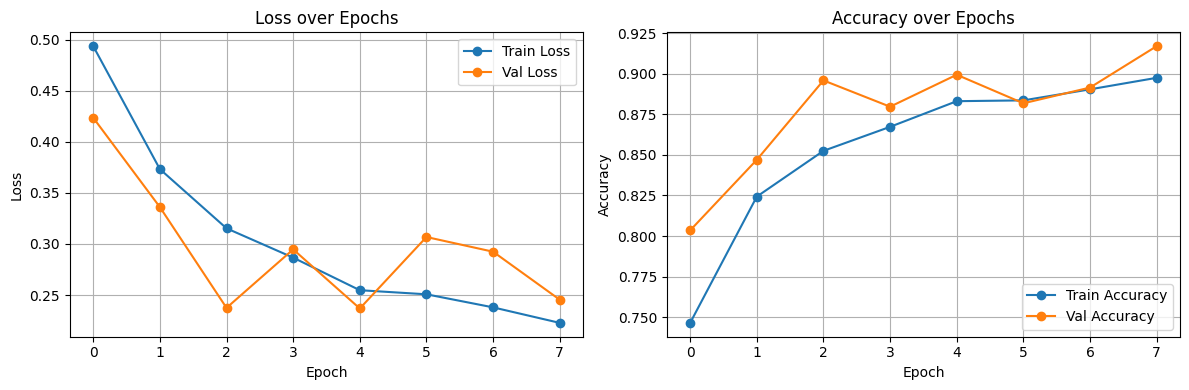

In [1]:
# All the numbers are taken from the logs in kaggle
import matplotlib.pyplot as plt

epochs = list(range(8))

train_loss = [0.4937, 0.3733, 0.3153, 0.2866, 0.2547, 0.2507, 0.2379, 0.2227]
val_loss   = [0.4236, 0.3361, 0.2374, 0.2947, 0.2368, 0.3068, 0.2924, 0.2454]
train_acc  = [0.7465, 0.8243, 0.8525, 0.8673, 0.8831, 0.8836, 0.8904, 0.8975]
val_acc    = [0.8035, 0.8470, 0.8959, 0.8797, 0.8994, 0.8818, 0.8915, 0.9170]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, label="Train Loss", marker="o")
ax1.plot(epochs, val_loss, label="Val Loss", marker="o")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_acc, label="Train Accuracy", marker="o")
ax2.plot(epochs, val_acc, label="Val Accuracy", marker="o")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

In [ ]:
import os
print(os.path.exists("/kaggle/input/notebooks/matteofioretti/deepfake-training/best_model.pth"))

TESTING THE MODEL


In [ ]:
# rebuild the model
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(2048,2)
model = model.to(device)


In [ ]:
# load learned parameters
state_dict = torch.load("/kaggle/input/notebooks/matteofioretti/deepfake-training/best_model.pth")
model.load_state_dict(state_dict)


In [ ]:
# test loop
model.eval()
all_labels = []
all_preds = []
all_probs = []

for batch in test_dataloader:
    with torch.no_grad():
        X, y = batch
        X,y = X.to(device), y.to(device)
        all_labels.extend(y.detach().cpu().numpy())
        y_hat = model(X)
        probs = torch.softmax(y_hat, dim=1)
        all_probs.extend(probs[:, 0].detach().cpu().numpy())
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())

In [ ]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              ConfusionMatrixDisplay)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs) 

confusion_mtx = confusion_matrix(all_labels, all_preds)
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, pos_label=0)
recall = recall_score(all_labels, all_preds, pos_label=0)
f1 = f1_score(all_labels, all_preds, pos_label=0)
roc_auc = roc_auc_score(all_labels, 1-all_probs)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mtx, display_labels=["fake", "real"])
disp.plot()

EVALUATION LOOP FOR ABLATION

In [ ]:
import os
print(os.path.exists("/kaggle/input/notebooks/matteofioretti/deepfake-ablation/best_model_scratch.pth"))

In [ ]:
# rebuild the model
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=None)
model.fc = nn.Linear(2048,2)
model = model.to(device)


In [ ]:
# load learned parameters
state_dict = torch.load("/kaggle/input/notebooks/matteofioretti/deepfake-ablation/best_model_scratch.pth")
model.load_state_dict(state_dict)


In [ ]:
# test loop
model.eval()
all_labels_scratch = []
all_preds_scratch = []
all_probs_scratch = []

for batch in test_dataloader:
    with torch.no_grad():
        X, y = batch
        X,y = X.to(device), y.to(device)
        all_labels_scratch.extend(y.detach().cpu().numpy())
        y_hat = model(X)
        probs = torch.softmax(y_hat, dim=1)
        all_probs_scratch.extend(probs[:, 0].detach().cpu().numpy())
        preds = torch.argmax(probs, dim=1)
        all_preds_scratch.extend(preds.detach().cpu().numpy())

In [ ]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              ConfusionMatrixDisplay)
all_labels_scratch = np.array(all_labels_scratch)
all_preds_scratch = np.array(all_preds_scratch)
all_probs_scratch = np.array(all_probs_scratch) 

confusion_mtx = confusion_matrix(all_labels_scratch, all_preds_scratch)
accuracy = accuracy_score(all_labels_scratch, all_preds_scratch)
precision = precision_score(all_labels_scratch, all_preds_scratch, pos_label=0)
recall = recall_score(all_labels_scratch, all_preds_scratch, pos_label=0)
f1 = f1_score(all_labels_scratch, all_preds_scratch, pos_label=0)
roc_auc = roc_auc_score(all_labels_scratch, 1-all_probs_scratch)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mtx, display_labels=["fake", "real"])
disp.plot()